# 02 LoRA 微调 Qwen3-8B

本 notebook 完成以下工作:
1. 生成合成训练数据 (使用 LLM API 批量生成猫咪内心独白)
2. 数据质量检查与清洗
3. LoRA 微调 Qwen3-8B
4. 微调前后效果对比

**核心技术**: LoRA (Low-Rank Adaptation) — 对应课程 Lec6

**预计耗时**: 数据生成 ~30min + 训练 ~1-2h (RTX 5080)

In [1]:
import json
import os
import random
from pathlib import Path
from itertools import product

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset

# 路径设置
DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
LORA_OUTPUT_DIR = Path("../models/monologue_lora")
LORA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"训练数据目录: {TRAIN_DIR.resolve()}")
print(f"LoRA 输出目录: {LORA_OUTPUT_DIR.resolve()}")

训练数据目录: /home/atlas/hajimi/data/train
LoRA 输出目录: /home/atlas/hajimi/models/monologue_lora


## 1. Load Pre-generated Training Data

Training data (288 samples) was previously generated using Claude Opus 4.6 API and saved to `data/train/`.

Format: 4 personas x 6 emotions x 3 body variants x 4 samples = 288 samples
- **catgirl**: ACG catgirl persona
- **hajimi**: Montagem Miau viral style
- **maodie**: Grumpy senior orange cat
- **general**: Normal cat natural reactions

Bilingual: 144 Chinese + 144 English samples

In [2]:
# Load pre-generated training data
# Data was generated using Claude Opus 4.6 API in a previous session
# No API key needed — we use the saved JSON files directly

raw_path = TRAIN_DIR / "monologue_raw.json"
train_path = TRAIN_DIR / "monologue_train.json"

assert raw_path.exists(), f"Raw data not found at {raw_path}"
assert train_path.exists(), f"Training data not found at {train_path}"

with open(raw_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

with open(train_path, "r", encoding="utf-8") as f:
    train_data_preview = json.load(f)

print(f"Raw samples: {len(raw_data)}")
print(f"Cleaned training samples: {len(train_data_preview)}")

# Show distribution
from collections import Counter
persona_counts = Counter(d["persona"] for d in raw_data)
lang_counts = Counter(d["language"] for d in raw_data)
print(f"\nBy persona: {dict(persona_counts)}")
print(f"By language: {dict(lang_counts)}")

# Show a sample
print(f"\nSample (catgirl/zh):")
print(f"  {raw_data[0]['monologue'][:100]}...")

Raw samples: 288
Cleaned training samples: 144

By persona: {'catgirl': 72, 'hajimi': 72, 'maodie': 72, 'general': 72}
By language: {'zh': 144, 'en': 144}

Sample (catgirl/zh):
  呜呜~好舒服喵~小猫把尾巴卷在身边，缩成一个小面包的形状，耳朵乖乖地朝前竖着。眼睛半眯着，感觉整个世界都暖融融的喵~主人今天的沙发好软好软，小猫不想动了喵。就让人家这样窝着吧，哪里都不想去~...


In [3]:
import sys
sys.path.insert(0, "..")
from src.prompts import PERSONA_SYSTEM_PROMPTS

EMOTIONS = ["relaxed", "curious", "fearful", "aggressive", "playful", "content"]
PERSONAS = ["catgirl", "hajimi", "maodie", "general"]

print(f"Personas: {PERSONAS}")
print(f"Emotions: {EMOTIONS}")
print(f"Persona prompts loaded: {list(PERSONA_SYSTEM_PROMPTS.keys())}")

Personas: ['catgirl', 'hajimi', 'maodie', 'general']
Emotions: ['relaxed', 'curious', 'fearful', 'aggressive', 'playful', 'content']
Persona prompts loaded: ['catgirl', 'hajimi', 'maodie', 'general']


### Data Generation Reference

The training data was generated by calling Claude Opus 4.6 API with the following approach:
- For each (persona, emotion, body_language_variant) combination, generated 2 Chinese + 2 English monologues
- Total: 4 personas x 6 emotions x 3 body variants x 4 samples = 288 raw samples
- API parameters: temperature=0.9, max_tokens=1500
- System prompts from `src/prompts.py` ensured persona consistency

The generation script is preserved below for reproducibility (commented out since data already exists).

In [4]:
# =============================================================
# Data generation code (SKIPPED — data already exists)
# =============================================================
# To regenerate, uncomment and set ANTHROPIC_API_KEY env var.
#
# import anthropic, time
# client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
#
# For each (persona, emotion, body_variant, language) combo:
#   response = client.messages.create(
#       model="claude-opus-4-6",
#       system=PERSONA_SYSTEM_PROMPTS[persona],
#       messages=[{"role": "user", "content": prompt}],
#       temperature=0.9, max_tokens=1500,
#   )
#   Parse response, split by "---", save to list
#
# See data/train/monologue_raw.json for the full output.
# =============================================================

print("Data generation SKIPPED — using pre-generated data from data/train/")
print(f"  monologue_raw.json:   {len(raw_data)} samples")
print(f"  monologue_train.json: {len(train_data_preview)} samples (after filtering)")

Data generation SKIPPED — using pre-generated data from data/train/
  monologue_raw.json:   288 samples
  monologue_train.json: 144 samples (after filtering)


## 2. 数据质量检查

Total samples: 288


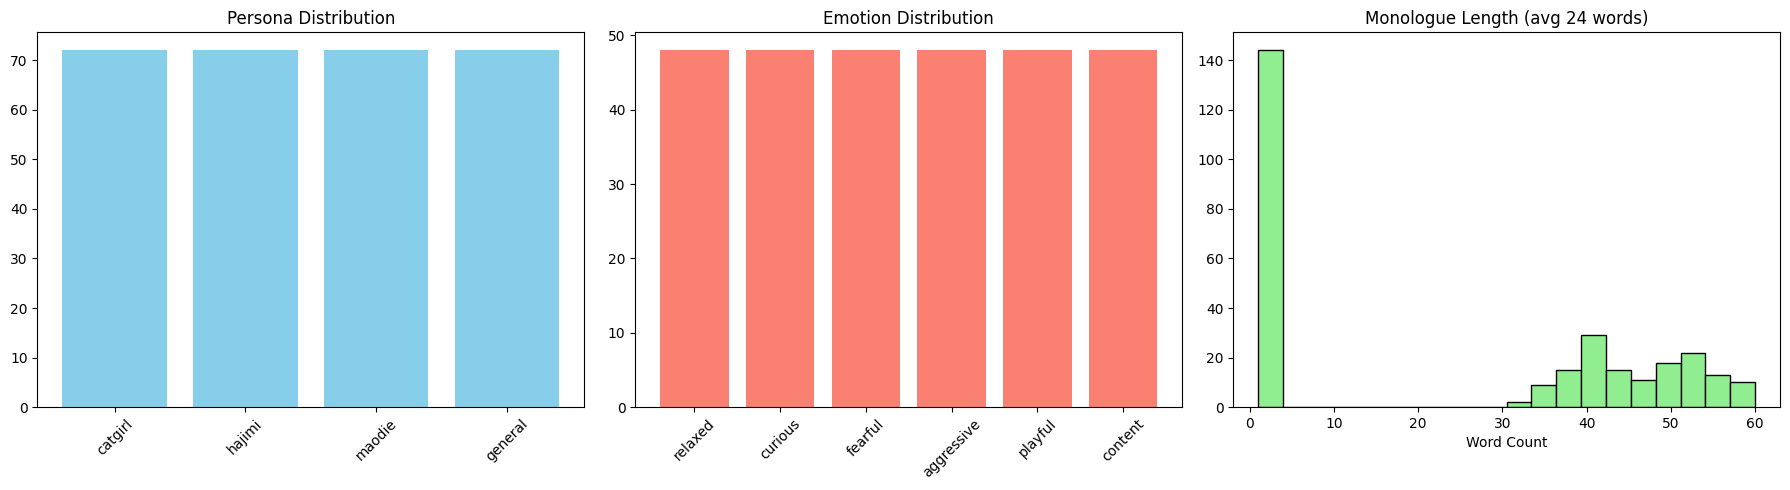

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
with open(TRAIN_DIR / "monologue_raw.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"Total samples: {len(raw_data)}")

# Count distributions
persona_counts = {}
emotion_counts = {}
lengths = []

for item in raw_data:
    p = item["persona"]
    e = item["emotion"]
    persona_counts[p] = persona_counts.get(p, 0) + 1
    emotion_counts[e] = emotion_counts.get(e, 0) + 1
    lengths.append(len(item["monologue"].split()))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Persona distribution
axes[0].bar(persona_counts.keys(), persona_counts.values(), color="skyblue")
axes[0].set_title("Persona Distribution")
axes[0].tick_params(axis="x", rotation=45)

# Emotion distribution
axes[1].bar(emotion_counts.keys(), emotion_counts.values(), color="salmon")
axes[1].set_title("Emotion Distribution")
axes[1].tick_params(axis="x", rotation=45)

# Length distribution
axes[2].hist(lengths, bins=20, color="lightgreen", edgecolor="black")
axes[2].set_title(f"Monologue Length (avg {np.mean(lengths):.0f} words)")
axes[2].set_xlabel("Word Count")

plt.tight_layout()
plt.show()

In [6]:
# Filter low-quality samples
# Criteria: too short (<15 words), too long (>150 words), or contains meta-text

filtered_data = []
removed_count = 0

BAD_PATTERNS = [
    "here is", "here's the", "monologue:", "inner monologue",
    "as a cat", "i'll write", "sure,", "certainly",
]

for item in raw_data:
    text = item["monologue"]
    word_count = len(text.split())
    
    if word_count < 15 or word_count > 150:
        removed_count += 1
        continue
    
    if any(pattern in text.lower()[:50] for pattern in BAD_PATTERNS):
        removed_count += 1
        continue
    
    filtered_data.append(item)

print(f"Before filtering: {len(raw_data)} samples")
print(f"After filtering:  {len(filtered_data)} samples")
print(f"Removed: {removed_count} low-quality samples")

# Save cleaned data
train_path = TRAIN_DIR / "monologue_train.json"
with open(train_path, "w", encoding="utf-8") as f:
    json.dump(filtered_data, f, indent=2, ensure_ascii=False)
print(f"\nTraining data saved: {train_path}")

Before filtering: 288 samples
After filtering:  144 samples
Removed: 144 low-quality samples

Training data saved: ../data/train/monologue_train.json


## 3. LoRA 微调 Qwen3-8B

使用 `peft` 库的 LoRA 方法微调 Qwen3-8B。

关键参数:
- LoRA rank: 16
- LoRA alpha: 32
- Target modules: q_proj, v_proj
- 训练 epochs: 3
- Learning rate: 2e-4

In [7]:
# 加载基础模型和 tokenizer
MODEL_ID = "Qwen/Qwen3-8B"

print("加载 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# 设置 padding token（Qwen 模型可能没有默认 pad token）
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("加载基础模型 (4-bit 量化)...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
)
base_model.config.use_cache = False  # 训练时关闭 KV cache

print(f"基础模型加载完成!")
if torch.cuda.is_available():
    print(f"显存占用: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

加载 tokenizer...


加载基础模型 (4-bit 量化)...


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

/home/atlas/miniconda3/envs/hajimi/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


基础模型加载完成!
显存占用: 5.67 GB


In [8]:
# 配置 LoRA
lora_config = LoraConfig(
    r=16,                                 # LoRA rank
    lora_alpha=32,                        # LoRA alpha (缩放因子)
    target_modules=["q_proj", "v_proj"],  # 应用 LoRA 的模块
    lora_dropout=0.05,                    # Dropout 防过拟合
    bias="none",                          # 不训练 bias
    task_type=TaskType.CAUSAL_LM,         # 因果语言模型任务
)

# 应用 LoRA 到基础模型
model = get_peft_model(base_model, lora_config)

# 显示可训练参数量
model.print_trainable_parameters()
# 预期输出类似: trainable params: 6,553,600 || all params: 8,036,257,792 || trainable%: 0.0816

trainable params: 7,667,712 || all params: 8,198,403,072 || trainable%: 0.0935


In [9]:
# 准备训练数据集
# 关键: 使用 tokenizer.apply_chat_template() 格式化数据
# 这是避免微调后输出无空格问题的核心!

with open(TRAIN_DIR / "monologue_train.json", "r") as f:
    train_data = json.load(f)

def format_training_example(item: dict) -> str:
    """
    将训练样本格式化为 chat template 格式
    
    关键: 使用 apply_chat_template 确保格式与模型预训练格式一致
    """
    persona = item["persona"]
    emotion = item["emotion"]
    body = item["body_language"]
    monologue = item["monologue"]
    
    # 构建 chat messages
    messages = [
        {
            "role": "system",
            "content": PERSONA_SYSTEM_PROMPTS[persona],
        },
        {
            "role": "user",
            "content": (
                f"Generate a short inner monologue for a cat.\n"
                f"Emotion: {emotion}\n"
                f"Body language: ears {body['ears']}, tail {body['tail']}, "
                f"{body['body_posture']}, eyes {body['eyes']}"
            ),
        },
        {
            "role": "assistant",
            "content": monologue,
        },
    ]
    
    # 使用 tokenizer 的 chat template 格式化
    return tokenizer.apply_chat_template(messages, tokenize=False)

# 格式化所有训练数据
formatted_texts = [format_training_example(item) for item in train_data]

# 展示一个格式化后的样本
print("格式化样本示例:")
print("=" * 60)
print(formatted_texts[0][:500])
print("...")

格式化样本示例:
<|im_start|>system
You are a CAT-GIRL (猫娘) — the classic anime catgirl archetype. You are cute, affectionate, and slightly clingy. You adore your master (主人) and crave attention. You use playful, coquettish speech patterns: trailing '~', 'nya~' (喵~), and act spoiled (撒娇). You refer to yourself in third person sometimes and get pouty when ignored. Mix in occasional Japanese/Chinese cute expressions naturally. You are sweet, loyal, and a little bit mischievous.
Example tone: 'Master~ why are you i
...


In [10]:
# Tokenize 训练数据
MAX_LENGTH = 512  # 最大序列长度

def tokenize_function(examples):
    """Tokenize 并生成 labels (只对 assistant 部分计算 loss)"""
    result = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    # labels = input_ids (自回归训练)
    result["labels"] = result["input_ids"].copy()
    return result

# 创建 HuggingFace Dataset
dataset = Dataset.from_dict({"text": formatted_texts})
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# 划分训练集和验证集 (90/10)
split = tokenized_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]

print(f"训练集: {len(train_dataset)} 条")
print(f"验证集: {len(eval_dataset)} 条")

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

训练集: 129 条
验证集: 15 条


In [11]:
# Training configuration
training_args = TrainingArguments(
    output_dir=str(LORA_OUTPUT_DIR / "checkpoints"),
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,        # effective batch_size = 16
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    fp16=True,
    report_to="none",
    dataloader_pin_memory=True,
    remove_unused_columns=False,
)

# Create Trainer (transformers 5.x renamed tokenizer -> processing_class)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

print("Training configured!")
print(f"Estimated total steps: ~{len(train_dataset) // 16 * 3}")

Training configured!
Estimated total steps: ~24


In [12]:
# 开始训练!
print("=" * 60)
print("开始 LoRA 微调...")
print("=" * 60)

trainer.train()

print("\n训练完成!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


开始 LoRA 微调...


Step,Training Loss,Validation Loss
27,5.400424,1.849402



训练完成!


In [13]:
# 保存 LoRA adapter
adapter_path = str(LORA_OUTPUT_DIR)
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"LoRA adapter 已保存到: {adapter_path}")
print("\n记得更新 configs/config.yaml 中的 use_lora: true")

LoRA adapter 已保存到: ../models/monologue_lora

记得更新 configs/config.yaml 中的 use_lora: true


## 4. 微调前后对比

In [14]:
# 对比: Base model vs LoRA model

test_cases = [
    {
        "persona": "catgirl",
        "emotion": "curious",
        "body": {"ears": "forward", "tail": "up high", "body_posture": "sitting upright", "eyes": "wide open"},
    },
    {
        "persona": "hajimi",
        "emotion": "playful",
        "body": {"ears": "forward", "tail": "swishing", "body_posture": "crouched", "eyes": "wide open"},
    },
    {
        "persona": "maodie",
        "emotion": "aggressive",
        "body": {"ears": "flattened", "tail": "puffed", "body_posture": "arched back", "eyes": "narrow"},
    },
    {
        "persona": "general",
        "emotion": "relaxed",
        "body": {"ears": "forward", "tail": "wrapped around body", "body_posture": "loaf position", "eyes": "half closed"},
    },
]

for tc in test_cases:
    print(f"\n{'=' * 60}")
    print(f"人格: {tc['persona']} | 情绪: {tc['emotion']}")
    print(f"{'=' * 60}")
    
    # 构建输入
    messages = [
        {"role": "system", "content": PERSONA_SYSTEM_PROMPTS[tc['persona']]},
        {"role": "user", "content": (
            f"Generate a short inner monologue for a cat.\n"
            f"Emotion: {tc['emotion']}\n"
            f"Body language: ears {tc['body']['ears']}, tail {tc['body']['tail']}, "
            f"{tc['body']['body_posture']}, eyes {tc['body']['eyes']}"
        )},
    ]
    
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    # LoRA 模型生成
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=200, temperature=0.85,
            top_p=0.9, do_sample=True,
        )
    generated = tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f"\n[LoRA 模型]:")
    print(generated.strip())


人格: catgirl | 情绪: curious


/home/atlas/miniconda3/envs/hajimi/lib/python3.11/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



[LoRA 模型]:
<think>
Okay, the user wants a short inner monologue for a cat with the emotion of curiosity. Let me start by recalling the key points. The emotion is curiosity, so the cat should be exploring or noticing something new. The body language includes ears forward, tail up high, sitting upright, and eyes wide open. That all suggests the cat is alert and interested.

I need to make sure the inner monologue reflects that curiosity. The cat is probably noticing something unusual or new in its environment. Since it's a catgirl, I should incorporate some cute expressions and Japanese terms like nya~ or ~. Also, the user mentioned using third person sometimes and being playful.

Let me think about the scenario. Maybe the cat is looking at something shiny or a new object. The tail being high and ears forward indicate alertness. The eyes wide open show fascination. The inner monologue should show the cat's thoughts about this discovery. Maybe the cat is wondering about the source of the

## ✅ LoRA 微调完成!

**下一步:**
1. 更新 `configs/config.yaml` 中 `use_lora: true`
2. 运行 `python app.py` 启动 Gradio Demo
3. 运行 `03_clip_ablation.ipynb` 进行 CLIP 消融实验